# EcoFarm 생태 농장 — 비상 발생 탐색적 데이터 분석 (EDA)

| 항목 | 내용 |
|------|------|
| 데이터 | `ecofarm_merged_dataset.csv` |
| 기간 | 2025-08-01 ~ 2026-07-31 |
| 레코드 | 21,900 (6개 시설 × 10시간 × 365일) |
| 분석 목적 | 비상 발생 패턴 파악 및 전처리 방향 도출 |

## 피처 목록

**시간/날짜 정보**

| 피처명 | 설명 |
|---|---|
| date | 날짜 (YYYY-MM-DD) |
| hour | 시간대 (09~18시, 운영시간 기준) |
| day_type | 평일/휴일 구분 (주말+공휴일 → 휴일) |
| season | 계절 (봄/여름/가을/겨울) |

**날씨 정보**

| 피처명 | 설명 |
|---|---|
| is_rain | 강수 여부 (True/False) |
| temperature | 기온(℃) |
| is_heatwave | 폭염 여부 (여름철 33℃ 이상) |
| is_coldwave | 한파 여부 (겨울철 -8℃ 이하) |

**시설 정보**

| 피처명 | 설명 |
|---|---|
| facility_id | 시설 고유 ID (F01~F06) |
| facility_name | 시설명 (캠핑장A/B, 전망대, 체험농장, 놀이시설존, 주차장/매표소) |
| facility_type | 시설 유형 (camping, observatory, experience, playground, gate) |
| capacity | 시설 최대 수용 인원 |
| x, y | 시설의 공간 좌표 (평면상 상대 위치) |
| base_risk | 시설별 기본 위험도 계수 (시설 특성상 원래 갖는 사고 발생 경향치) |

**방문객 정보**

| 피처명 | 설명 |
|---|---|
| visitor_count | 해당 날짜·시간·시설의 방문객 수 |
| density | 밀집도 (visitor_count / capacity, 0~1) |

**응급상황 정보 (타깃 변수 포함)**

| 피처명 | 설명 |
|---|---|
| emergency_occurred | 해당 시간·시설에 응급상황 발생 여부 (0/1) — **예측 타깃** |
| emergency_count | 해당 시간·시설에 발생한 응급상황 건수 |
| emergency_types | 발생한 응급상황 유형(들), 여러 건이면 `\|`로 구분 (예: 낙상, 열사병, 심정지, 골절 등) |
| max_severity | 발생한 응급상황 중 최고 중증도 (경증/중등증/중증) |
| avg_response_time_min | 해당 응급상황들의 평균 대응 소요시간(분) |

In [1]:
import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── 팔레트 ────────────────────────────────────────────────────────────────
S1='#2a78d6'; S2='#eb6834'; S3='#1baf7a'; S4='#eda100'
S8='#e34948'
SURF='#fcfcfb'; SURF0='#f4f4f2'
GRID='#e1e0d9'; TEXTM='#898781'; TEXTS='#52514e'; TEXTP='#0b0b0b'
SEQ = ['#cde2fb','#9ec5f4','#86b6ef','#6da7ec','#5598e7',
       '#3987e5','#2a78d6','#256abf','#184f95','#0d366b']
blue_cmap = LinearSegmentedColormap.from_list('sb', SEQ)

plt.rcParams.update({
    'axes.facecolor': SURF, 'figure.facecolor': SURF0,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GRID, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.labelcolor': TEXTM, 'xtick.color': TEXTM, 'ytick.color': TEXTM,
    'text.color': TEXTP,
})

def seq_colors(vals):
    mn, mx = min(vals), max(vals)
    return [blue_cmap((v - mn) / (mx - mn + 1e-9)) for v in vals]

print('라이브러리 로드 완료')

라이브러리 로드 완료


---
## 1. 데이터 로드 및 기본 구조 확인

In [2]:
df = pd.read_csv('ecofarm_merged_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

print(f'Shape: {df.shape}')
print(f'기간: {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'시설 수: {df["facility_id"].nunique()}개')
df.head(3)

Shape: (21900, 22)
기간: 2025-08-01 ~ 2026-07-31
시설 수: 6개


,date,hour,day_type,season,is_rain,temperature,is_heatwave,is_coldwave,facility_id,facility_name,...,x,y,base_risk,visitor_count,density,emergency_occurred,emergency_count,emergency_types,max_severity,avg_response_time_min
0,2025-08-01,9,평일,여름,False,24.8,False,False,F01,캠핑장A,...,10,20,0.015,44,0.147,0,0,NaN,NaN,NaN
1,2025-08-01,10,평일,여름,False,24.8,False,False,F01,캠핑장A,...,10,20,0.015,67,0.223,1,1,심정지,경증,11.0
2,2025-08-01,11,평일,여름,False,24.8,False,False,F01,캠핑장A,...,10,20,0.015,77,0.257,0,0,NaN,NaN,NaN


In [3]:
print('=== 데이터 타입 ===')
print(df.dtypes)
print()
print('=== 결측값 ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'결측 수': missing, '결측률(%)': missing_pct})[missing > 0]

=== 데이터 타입 ===
date                     datetime64[us]
hour                              int64
day_type                            str
season                              str
is_rain                            bool
temperature                     float64
is_heatwave                        bool
is_coldwave                        bool
facility_id                         str
facility_name                       str
facility_type                       str
capacity                          int64
x                                 int64
y                                 int64
base_risk                       float64
visitor_count                     int64
density                         float64
emergency_occurred                int64
emergency_count                   int64
emergency_types                     str
max_severity                        str
avg_response_time_min           float64
dtype: object

=== 결측값 ===


,결측 수,결측률(%)
emergency_types,21064,96.18
max_severity,21064,96.18
avg_response_time_min,21064,96.18


In [4]:
print('=== 수치형 컬럼 기술통계 ===')
df.describe().T.round(3)

=== 수치형 컬럼 기술통계 ===


,count,mean,min,25%,50%,75%,max,std
date,21900,2026-01-30 00:00:00,2025-08-01 00:00:00,2025-10-31 00:00:00,2026-01-30 00:00:00,2026-05-01 00:00:00,2026-07-31 00:00:00,NaN
hour,21900.0,13.5,9.0,11.0,13.5,16.0,18.0,2.872347
temperature,21900.0,16.755342,-7.1,8.8,17.9,23.9,40.7,10.481508
capacity,21900.0,246.666667,150.0,180.0,225.0,300.0,400.0,83.999272
x,21900.0,20.833333,5.0,10.0,20.0,30.0,40.0,12.047635
y,21900.0,27.5,5.0,10.0,22.5,45.0,60.0,19.311491
base_risk,21900.0,0.0155,0.008,0.01,0.015,0.02,0.025,0.005737
visitor_count,21900.0,70.093653,1.0,33.0,56.0,91.0,378.0,51.912236
density,21900.0,0.284168,0.005,0.153,0.24,0.378,1.0,0.177572
emergency_occurred,21900.0,0.038174,0.0,0.0,0.0,0.0,1.0,0.191619


In [5]:
for col in ['day_type', 'season', 'facility_type', 'max_severity', 'emergency_types']:
    print(f'[{col}]')
    print(df[col].value_counts(dropna=False).to_string())
    print()

[day_type]
day_type
평일    15000
휴일     6900

[season]
season
여름    5520
봄     5520
가을    5460
겨울    5400

[facility_type]
facility_type
camping        7300
observatory    3650
experience     3650
playground     3650
gate           3650

[max_severity]
max_severity
NaN    21064
경증       500
중등증      249
중증        87

[emergency_types]
emergency_types
NaN     21064
낙상        215
심정지       123
화상         69
골절         67
열사병        66
충돌사고       64
식중독        61
교통사고       42
알레르기       38
실신         36
미아         28
동물물림       27



In [6]:
print('=== 시설 목록 ===')
df[['facility_id','facility_name','facility_type','capacity']].drop_duplicates().sort_values('facility_id')

=== 시설 목록 ===


,facility_id,facility_name,facility_type,capacity
0,F01,캠핑장A,camping,300
10,F02,캠핑장B,camping,200
20,F03,전망대,observatory,150
30,F04,체험농장,experience,250
40,F05,놀이시설존,playground,180
50,F06,주차장/매표소,gate,400


---
## 2. 비상 발생 패턴 — 시설별 · 시간대별 · 계절별

In [7]:
def emerg_rate(group_col):
    return df.groupby(group_col)['emergency_occurred'].agg(
        발생건수='sum', 총레코드='count',
        발생률=lambda x: round(x.mean()*100, 2)
    )

print('--- 시설 유형별 ---')
print(emerg_rate('facility_type'), '\n')
print('--- 계절별 ---')
print(emerg_rate('season'), '\n')
print('--- 시간대별 ---')
print(emerg_rate('hour'))

--- 시설 유형별 ---
               발생건수  총레코드   발생률
facility_type                  
camping         259  7300  3.55
experience      112  3650  3.07
gate            106  3650  2.90
observatory     179  3650  4.90
playground      180  3650  4.93 

--- 계절별 ---
        발생건수  총레코드   발생률
season                  
가을       198  5460  3.63
겨울       152  5400  2.81
봄        196  5520  3.55
여름       290  5520  5.25 

--- 시간대별 ---
      발생건수  총레코드   발생률
hour                  
9       56  2190  2.56
10      64  2190  2.92
11      86  2190  3.93
12      86  2190  3.93
13     113  2190  5.16
14      88  2190  4.02
15     115  2190  5.25
16      83  2190  3.79
17      77  2190  3.52
18      68  2190  3.11


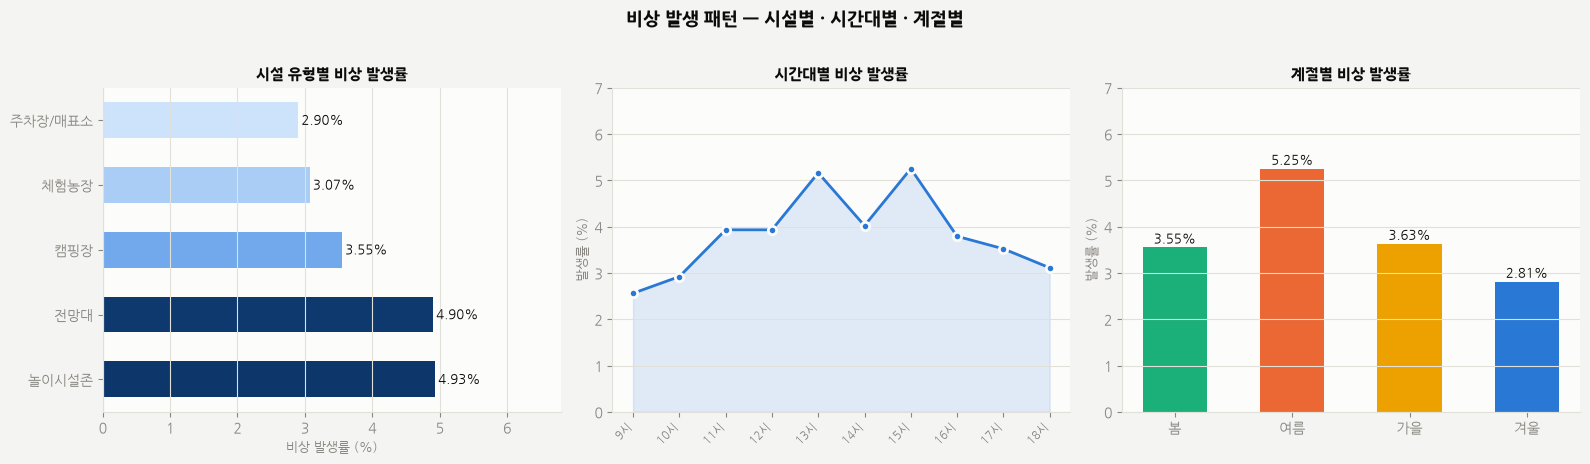

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), facecolor=SURF0)
fig.suptitle('비상 발생 패턴 — 시설별 · 시간대별 · 계절별', fontsize=13, fontweight='bold', y=1.02)

# 시설별
ax = axes[0]
data = [('놀이시설존',4.93),('전망대',4.90),('캠핑장',3.55),('체험농장',3.07),('주차장/매표소',2.90)]
lbls, vals = zip(*data)
bars = ax.barh(lbls, vals, color=seq_colors(vals), height=0.55, edgecolor='none')
for b, v in zip(bars, vals):
    ax.text(v+0.05, b.get_y()+b.get_height()/2, f'{v:.2f}%', va='center', fontsize=9)
ax.set_xlabel('비상 발생률 (%)', fontsize=9)
ax.set_title('시설 유형별 비상 발생률', fontsize=11, fontweight='bold')
ax.set_xlim(0, 6.8)
ax.grid(axis='x'); ax.grid(axis='y', visible=False)

# 시간대별
ax = axes[1]
hrs = list(range(9, 19))
hv  = [2.56,2.92,3.93,3.93,5.16,4.02,5.25,3.79,3.52,3.11]
ax.plot(hrs, hv, color=S1, lw=2, marker='o', ms=6, mfc=S1, mec=SURF, mew=2)
ax.fill_between(hrs, hv, alpha=0.13, color=S1)
ax.set_xticks(hrs)
ax.set_xticklabels([f'{h}시' for h in hrs], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('발생률 (%)', fontsize=9); ax.set_ylim(0, 7)
ax.set_title('시간대별 비상 발생률', fontsize=11, fontweight='bold')
ax.grid(axis='y'); ax.grid(axis='x', visible=False)
ax.spines['left'].set_color(GRID)

# 계절별
ax = axes[2]
bars = ax.bar(['봄','여름','가을','겨울'], [3.55,5.25,3.63,2.81],
              color=[S3,S2,S4,S1], width=0.55, edgecolor='none')
for b, v in zip(bars, [3.55,5.25,3.63,2.81]):
    ax.text(b.get_x()+b.get_width()/2, v+0.05, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('발생률 (%)', fontsize=9); ax.set_ylim(0, 7)
ax.set_title('계절별 비상 발생률', fontsize=11, fontweight='bold')
ax.grid(axis='y'); ax.grid(axis='x', visible=False)
ax.spines['left'].set_color(GRID)

plt.tight_layout()
plt.show()

---
## 3. 기상 조건 및 밀도 영향

In [9]:
print('--- 폭염 여부별 ---')
print(df.groupby('is_heatwave')['emergency_occurred'].agg(['sum','count','mean']).round(4), '\n')
print('--- 강우 여부별 ---')
print(df.groupby('is_rain')['emergency_occurred'].agg(['sum','count','mean']).round(4), '\n')
print('--- 평일/휴일별 ---')
print(df.groupby('day_type')['emergency_occurred'].agg(['sum','count','mean']).round(4), '\n')

df['temp_bin'] = pd.cut(df['temperature'],
    bins=[-10,0,10,20,30,45],
    labels=['영하','0-10°C','10-20°C','20-30°C','30°C+'])
print('--- 온도 구간별 ---')
print(df.groupby('temp_bin', observed=True)['emergency_occurred']
      .agg(['sum','count','mean']).round(4))

--- 폭염 여부별 ---
             sum  count    mean
is_heatwave                    
False        753  21000  0.0359
True          83    900  0.0922 

--- 강우 여부별 ---
         sum  count    mean
is_rain                    
False    684  17520  0.0390
True     152   4380  0.0347 

--- 평일/휴일별 ---
          sum  count    mean
day_type                    
평일        453  15000  0.0302
휴일        383   6900  0.0555 

--- 온도 구간별 ---
          sum  count    mean
temp_bin                    
영하         48   1560  0.0308
0-10°C    116   4140  0.0280
10-20°C   269   7320  0.0367
20-30°C   256   6600  0.0388
30°C+     147   2280  0.0645


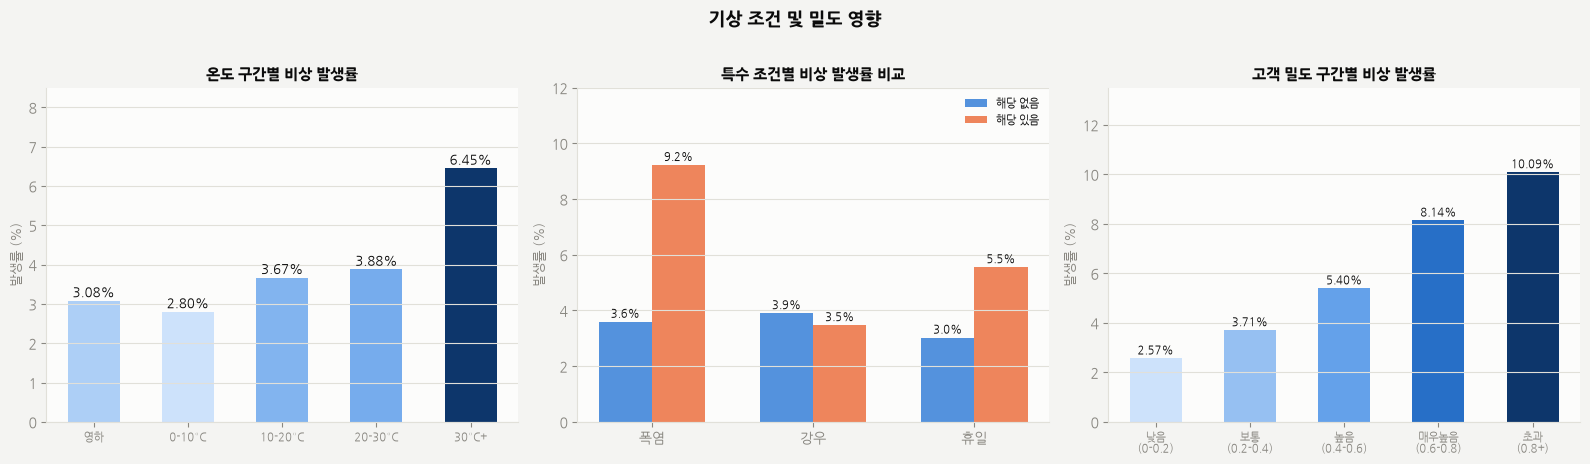

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), facecolor=SURF0)
fig.suptitle('기상 조건 및 밀도 영향', fontsize=13, fontweight='bold', y=1.02)

# 온도 구간
ax = axes[0]
tlbls = ['영하','0-10°C','10-20°C','20-30°C','30°C+']
tv    = [3.08,2.80,3.67,3.88,6.45]
bars  = ax.bar(tlbls, tv, color=seq_colors(tv), width=0.55, edgecolor='none')
for b,v in zip(bars,tv):
    ax.text(b.get_x()+b.get_width()/2, v+0.05, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('발생률 (%)', fontsize=9); ax.set_ylim(0, 8.5)
ax.set_title('온도 구간별 비상 발생률', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', labelsize=8)
ax.grid(axis='y'); ax.grid(axis='x', visible=False)
ax.spines['left'].set_color(GRID)

# 특수 조건 비교
ax = axes[1]
xpos = np.arange(3); w = 0.33
b1 = ax.bar(xpos-w/2, [3.59,3.90,3.02], w, color=S1+'cc', edgecolor='none', label='해당 없음')
b2 = ax.bar(xpos+w/2, [9.22,3.47,5.55], w, color=S2+'cc', edgecolor='none', label='해당 있음')
for b,v in zip(b1,[3.59,3.90,3.02]):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
for b,v in zip(b2,[9.22,3.47,5.55]):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_xticks(xpos); ax.set_xticklabels(['폭염','강우','휴일'])
ax.set_ylabel('발생률 (%)', fontsize=9); ax.set_ylim(0, 12)
ax.set_title('특수 조건별 비상 발생률 비교', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.grid(axis='y'); ax.grid(axis='x', visible=False)
ax.spines['left'].set_color(GRID)

# 밀도 구간
ax = axes[2]
df['density_bin'] = pd.cut(df['density'],
    bins=[0,0.2,0.4,0.6,0.8,1.1],
    labels=['낮음\n(0-0.2)','보통\n(0.2-0.4)','높음\n(0.4-0.6)','매우높음\n(0.6-0.8)','초과\n(0.8+)'])
dlbls = ['낮음\n(0-0.2)','보통\n(0.2-0.4)','높음\n(0.4-0.6)','매우높음\n(0.6-0.8)','초과\n(0.8+)']
dv    = [2.57,3.71,5.40,8.14,10.09]
bars  = ax.bar(dlbls, dv, color=seq_colors(dv), width=0.55, edgecolor='none')
for b,v in zip(bars,dv):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('발생률 (%)', fontsize=9); ax.set_ylim(0, 13.5)
ax.set_title('고객 밀도 구간별 비상 발생률', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', labelsize=8)
ax.grid(axis='y'); ax.grid(axis='x', visible=False)
ax.spines['left'].set_color(GRID)

plt.tight_layout()
plt.show()

---
## 4. 응급 유형 및 중증도 분포

In [12]:
emerg = df[df['emergency_occurred'] == 1].copy()
print(f'비상 발생 레코드: {len(emerg)}건\n')
print('--- 응급 유형별 빈도 ---')
print(emerg['emergency_types'].value_counts(), '\n')
print('--- 중증도 분포 ---')
print(emerg['max_severity'].value_counts(), '\n')

sev_cross = emerg.groupby(['emergency_types','max_severity']).size().unstack(fill_value=0)
sev_cross['합계'] = sev_cross.sum(axis=1)
sev_cross['중증비율(%)'] = (sev_cross['중증'] / sev_cross['합계'] * 100).round(1)
print('--- 응급 유형 × 중증도 ---')
sev_cross.sort_values('중증비율(%)', ascending=False)

비상 발생 레코드: 836건

--- 응급 유형별 빈도 ---
emergency_types
낙상      215
심정지     123
화상       69
골절       67
열사병      66
충돌사고     64
식중독      61
교통사고     42
알레르기     38
실신       36
미아       28
동물물림     27
Name: count, dtype: int64 

--- 중증도 분포 ---
max_severity
경증     500
중등증    249
중증      87
Name: count, dtype: int64 

--- 응급 유형 × 중증도 ---


max_severity,경증,중등증,중증,합계,중증비율(%)
emergency_types,,,,,
열사병,37,18,11,66,16.7
식중독,34,17,10,61,16.4
낙상,128,56,31,215,14.4
동물물림,13,11,3,27,11.1
교통사고,21,17,4,42,9.5
실신,21,12,3,36,8.3
심정지,82,31,10,123,8.1
알레르기,24,11,3,38,7.9
미아,20,6,2,28,7.1


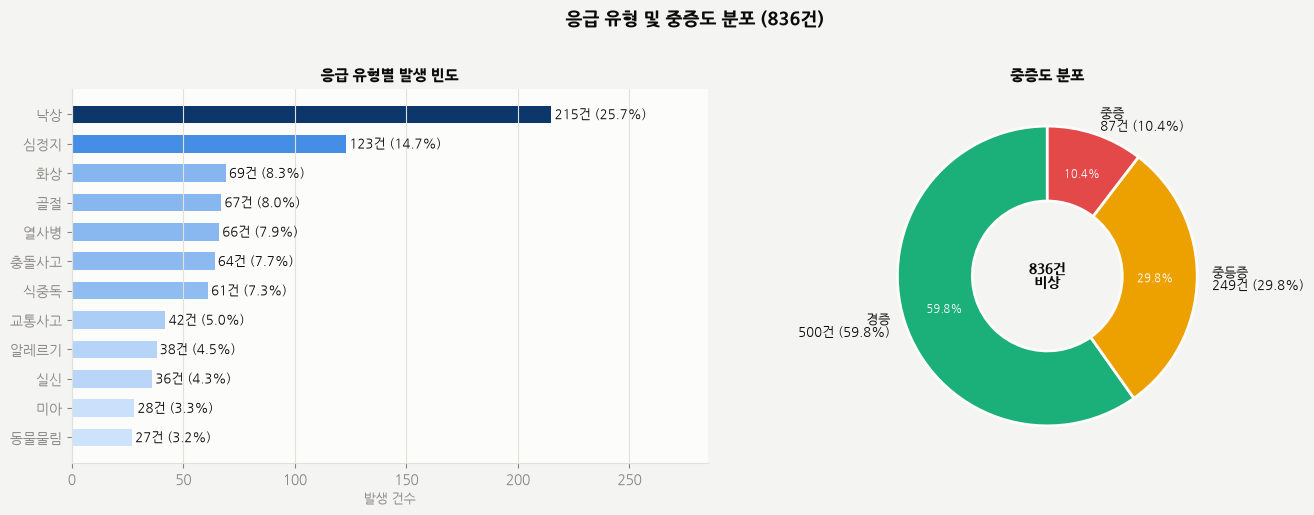

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=SURF0)
fig.suptitle('응급 유형 및 중증도 분포 (836건)', fontsize=13, fontweight='bold', y=1.02)

# 응급 유형 빈도
ax = axes[0]
edata = sorted([
    ('낙상',215),('심정지',123),('충돌사고',64),('화상',69),('골절',67),
    ('열사병',66),('식중독',61),('교통사고',42),('알레르기',38),('실신',36),('미아',28),('동물물림',27)
], key=lambda x:x[1])
el, ev = zip(*edata)
bars = ax.barh(el, ev, color=seq_colors(ev), height=0.6, edgecolor='none')
for b,v in zip(bars,ev):
    ax.text(v+1.5, b.get_y()+b.get_height()/2, f'{v}건 ({v/836*100:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('발생 건수', fontsize=9); ax.set_xlim(0, 285)
ax.set_title('응급 유형별 발생 빈도', fontsize=11, fontweight='bold')
ax.grid(axis='x'); ax.grid(axis='y', visible=False)

# 중증도 도넛
ax = axes[1]
ax.set_facecolor(SURF)
wedges, texts, autotexts = ax.pie(
    [500,249,87],
    labels=['경증\n500건 (59.8%)','중등증\n249건 (29.8%)','중증\n87건 (10.4%)'],
    colors=[S3,S4,S8],
    autopct='%1.1f%%', pctdistance=0.72,
    wedgeprops={'width':0.5,'edgecolor':SURF,'linewidth':2},
    startangle=90, textprops={'fontsize':9}
)
for at in autotexts:
    at.set_fontsize(8); at.set_color('white')
ax.text(0,0,'836건\n비상', ha='center', va='center', fontsize=10, fontweight='bold')
ax.set_title('중증도 분포', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 5. 대응 시간 분석

In [14]:
print('--- 전체 대응 시간 기술통계 ---')
print(emerg['avg_response_time_min'].describe().round(2), '\n')
print('--- 중증도별 대응 시간 ---')
print(emerg.groupby('max_severity')['avg_response_time_min'].describe().round(2), '\n')
print('--- 시설별 대응 시간 ---')
print(emerg.groupby('facility_type')['avg_response_time_min'].describe().round(2))

--- 전체 대응 시간 기술통계 ---
count    836.00
mean       9.60
std        3.24
min        2.00
25%        7.00
50%       10.00
75%       12.00
max       18.00
Name: avg_response_time_min, dtype: float64 

--- 중증도별 대응 시간 ---
              count   mean   std  min   25%   50%   75%   max
max_severity                                                 
경증            500.0  11.52  2.11  5.0  10.0  12.0  13.0  18.0
중등증           249.0   7.54  2.02  3.0   6.0   7.0   9.0  14.0
중증             87.0   4.44  1.92  2.0   3.0   4.0   6.0   9.0 

--- 시설별 대응 시간 ---
               count  mean   std  min  25%   50%   75%   max
facility_type                                               
camping        259.0  9.48  3.36  2.0  7.0  10.0  12.0  17.0
experience     112.0  9.36  3.08  2.0  7.0  10.0  12.0  18.0
gate           106.0  9.70  2.97  2.0  8.0  10.0  12.0  15.0
observatory    179.0  9.55  3.24  2.0  7.0  10.0  12.0  17.0
playground     180.0  9.90  3.33  2.0  8.0  10.0  12.0  17.0


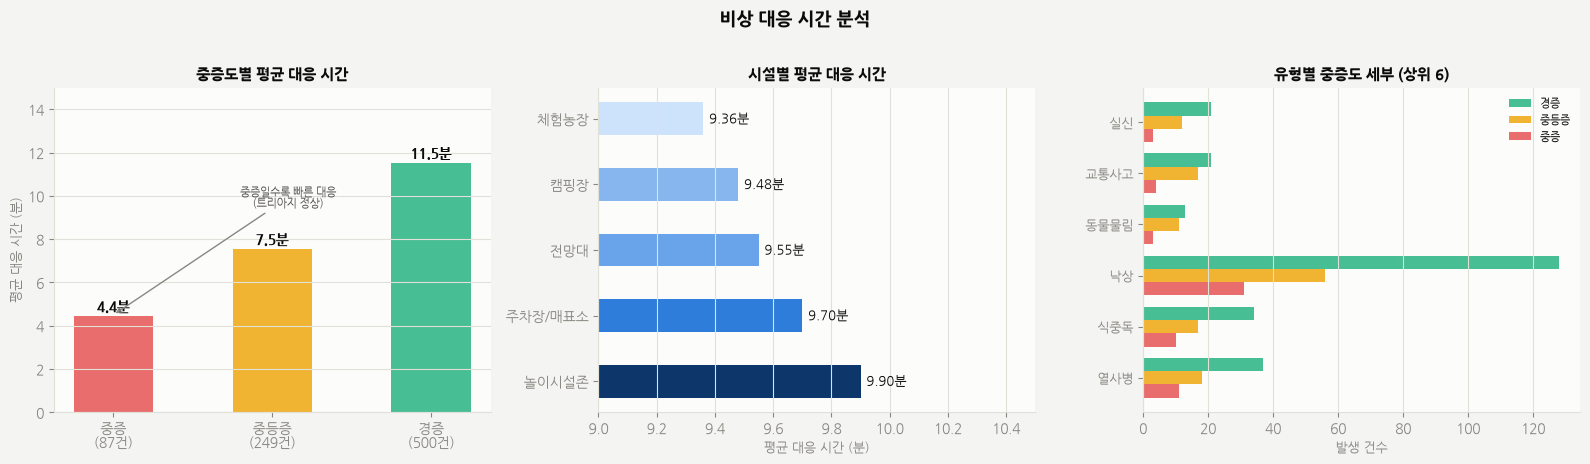

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), facecolor=SURF0)
fig.suptitle('비상 대응 시간 분석', fontsize=13, fontweight='bold', y=1.02)

# 중증도별
ax = axes[0]
bars = ax.bar(['중증\n(87건)','중등증\n(249건)','경증\n(500건)'],
              [4.44,7.54,11.52],
              color=[S8+'cc',S4+'cc',S3+'cc'], width=0.5, edgecolor='none')
for b,v in zip(bars,[4.44,7.54,11.52]):
    ax.text(b.get_x()+b.get_width()/2, v+0.1, f'{v:.1f}분',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('평균 대응 시간 (분)', fontsize=9); ax.set_ylim(0, 15)
ax.set_title('중증도별 평균 대응 시간', fontsize=11, fontweight='bold')
ax.annotate('중증일수록 빠른 대응\n(트리아지 정상)', xy=(0,4.5), xytext=(1.1,9.5),
            fontsize=8, color=TEXTS, ha='center',
            arrowprops=dict(arrowstyle='->', color=TEXTM, lw=1))
ax.grid(axis='y'); ax.grid(axis='x', visible=False)
ax.spines['left'].set_color(GRID)

# 시설별
ax = axes[1]
fdata = [('놀이시설존',9.90),('주차장/매표소',9.70),('전망대',9.55),('캠핑장',9.48),('체험농장',9.36)]
fl, fv = zip(*fdata)
bars = ax.barh(fl, fv, color=seq_colors(fv), height=0.5, edgecolor='none')
for b,v in zip(bars,fv):
    ax.text(v+0.02, b.get_y()+b.get_height()/2, f'{v:.2f}분', va='center', fontsize=9)
ax.set_xlabel('평균 대응 시간 (분)', fontsize=9); ax.set_xlim(9.0, 10.5)
ax.set_title('시설별 평균 대응 시간', fontsize=11, fontweight='bold')
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
ax.spines['bottom'].set_color(GRID)

# 유형별 중증도 세부
ax = axes[2]
etypes = ['열사병','식중독','낙상','동물물림','교통사고','실신']
mild   = [37,34,128,13,21,21]
mod    = [18,17,56,11,17,12]
sev2   = [11,10,31,3,4,3]
y = np.arange(len(etypes)); w = 0.26
ax.barh(y+w, mild, w, color=S3+'cc', edgecolor='none', label='경증')
ax.barh(y,   mod,  w, color=S4+'cc', edgecolor='none', label='중등증')
ax.barh(y-w, sev2, w, color=S8+'cc', edgecolor='none', label='중증')
ax.set_yticks(y); ax.set_yticklabels(etypes, fontsize=9)
ax.set_xlabel('발생 건수', fontsize=9)
ax.set_title('유형별 중증도 세부 (상위 6)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
ax.spines['bottom'].set_color(GRID)

plt.tight_layout()
plt.show()

---
## 6. 히트맵 분석

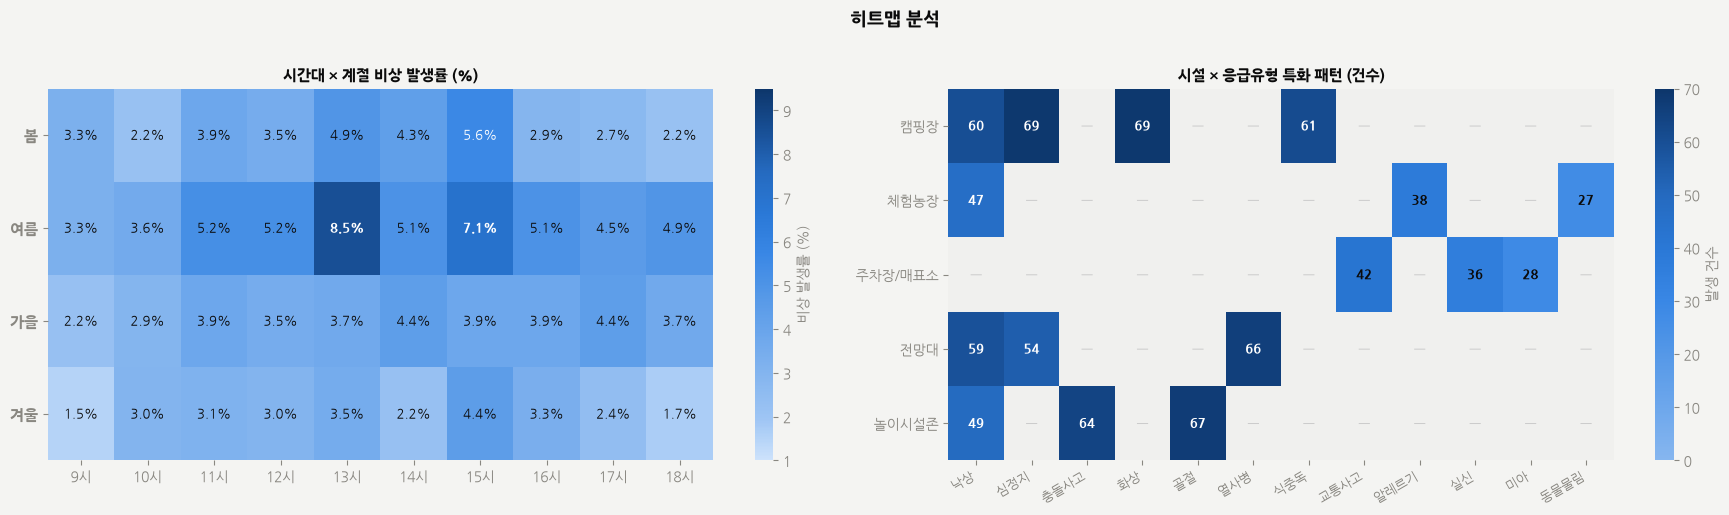

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=SURF0)
fig.suptitle('히트맵 분석', fontsize=13, fontweight='bold', y=1.02)

# 시간 × 계절
ax = axes[0]
hm = np.array([
    [3.26,2.17,3.85,3.48,4.89,4.35,5.62,2.90,2.72,2.17],
    [3.26,3.62,5.25,5.25,8.51,5.07,7.07,5.07,4.53,4.89],
    [2.20,2.93,3.85,3.48,3.66,4.40,3.85,3.85,4.40,3.66],
    [1.48,2.96,3.15,2.96,3.52,2.22,4.44,3.33,2.41,1.67],
])
im = ax.imshow(hm, cmap=blue_cmap, aspect='auto', vmin=1.0, vmax=9.5)
ax.set_xticks(range(10)); ax.set_xticklabels([f'{h}시' for h in range(9,19)], fontsize=10)
ax.set_yticks(range(4));  ax.set_yticklabels(['봄','여름','가을','겨울'], fontsize=11, fontweight='bold')
ax.set_title('시간대 × 계절 비상 발생률 (%)', fontsize=11, fontweight='bold')
ax.grid(visible=False); ax.spines[:].set_visible(False)
for si in range(4):
    for hi in range(10):
        v = hm[si,hi]
        tc = 'white' if v > 5.5 else TEXTP
        ax.text(hi, si, f'{v:.1f}%', ha='center', va='center', fontsize=9,
                fontweight='bold' if v>6.5 else 'normal', color=tc)
plt.colorbar(im, ax=ax, label='비상 발생률 (%)').outline.set_visible(False)

# 시설 × 응급유형
ax = axes[1]
facs   = ['캠핑장','체험농장','주차장/매표소','전망대','놀이시설존']
etypes = ['낙상','심정지','충돌사고','화상','골절','열사병','식중독','교통사고','알레르기','실신','미아','동물물림']
mat = np.array([
    [60,69, 0,69, 0, 0,61, 0, 0, 0, 0, 0],
    [47, 0, 0, 0, 0, 0, 0, 0,38, 0, 0,27],
    [ 0, 0, 0, 0, 0, 0, 0,42, 0,36,28, 0],
    [59,54, 0, 0, 0,66, 0, 0, 0, 0, 0, 0],
    [49, 0,64, 0,67, 0, 0, 0, 0, 0, 0, 0],
], dtype=float)
mat_m = np.ma.masked_where(mat==0, mat)
cmap2 = LinearSegmentedColormap.from_list('sb2', SEQ[2:])
cmap2.set_bad(color='#f0f0ee')
im2 = ax.imshow(mat_m, cmap=cmap2, aspect='auto', vmin=0, vmax=70)
ax.set_xticks(range(len(etypes))); ax.set_xticklabels(etypes, fontsize=9, rotation=30, ha='right')
ax.set_yticks(range(len(facs)));   ax.set_yticklabels(facs, fontsize=10)
ax.set_title('시설 × 응급유형 특화 패턴 (건수)', fontsize=11, fontweight='bold')
ax.grid(visible=False); ax.spines[:].set_visible(False)
for fi in range(len(facs)):
    for ei in range(len(etypes)):
        v = mat[fi,ei]
        if v > 0:
            ax.text(ei, fi, str(int(v)), ha='center', va='center', fontsize=9,
                    color='white' if v>45 else TEXTP, fontweight='bold')
        else:
            ax.text(ei, fi, '—', ha='center', va='center', fontsize=9, color='#cccccc')
plt.colorbar(im2, ax=ax, label='발생 건수').outline.set_visible(False)

plt.tight_layout()
plt.show()

---
## 7. 상관관계 분석

=== 수치형 컬럼 상관계수 행렬 ===
                       temperature  visitor_count  density  base_risk  \
temperature                 1.0000         0.2925   0.3465     0.0000   
visitor_count               0.2925         1.0000   0.8404    -0.3556   
density                     0.3465         0.8404   1.0000     0.0012   
base_risk                   0.0000        -0.3556   0.0012     1.0000   
emergency_occurred          0.0478         0.0542   0.0862     0.0405   
avg_response_time_min      -0.0307        -0.0260  -0.0244     0.0359   

                       emergency_occurred  avg_response_time_min  
temperature                        0.0478                -0.0307  
visitor_count                      0.0542                -0.0260  
density                            0.0862                -0.0244  
base_risk                          0.0405                 0.0359  
emergency_occurred                 1.0000                    NaN  
avg_response_time_min                 NaN                 1.000

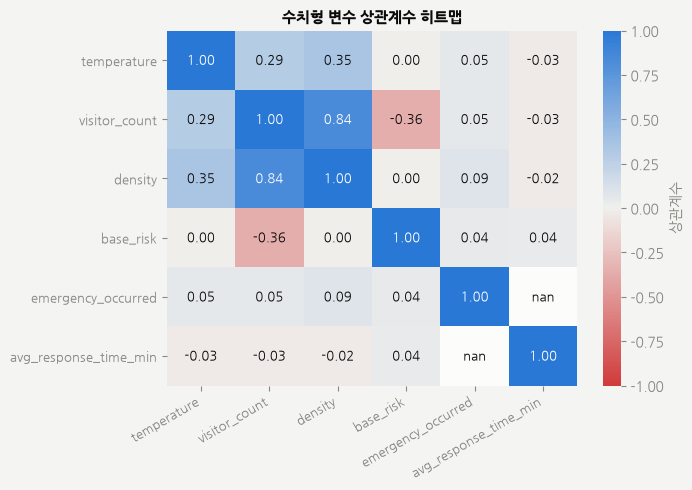

In [17]:
num_cols = ['temperature','visitor_count','density','base_risk','emergency_occurred','avg_response_time_min']
corr = df[num_cols].corr().round(4)

print('=== 수치형 컬럼 상관계수 행렬 ===')
print(corr)

fig, ax = plt.subplots(figsize=(7, 5), facecolor=SURF0)
div_cmap = LinearSegmentedColormap.from_list('div', ['#d03b3b','#f0efec','#2a78d6'])
im = ax.imshow(corr.values, cmap=div_cmap, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols, fontsize=9)
ax.set_title('수치형 변수 상관계수 히트맵', fontsize=11, fontweight='bold')
ax.grid(visible=False); ax.spines[:].set_visible(False)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        v = corr.values[i,j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v)>0.6 else TEXTP)
plt.colorbar(im, ax=ax, label='상관계수').outline.set_visible(False)
plt.tight_layout()
plt.show()

---
## 8. 전처리 권고사항

EDA 결과를 바탕으로 모델링 전 수행해야 할 전처리 항목입니다.

---

### ① 결측값 처리

| 컬럼 | 결측 건수 | 원인 | 처리 방법 |
|------|-----------|------|-----------|
| `emergency_types` | 21,064 | 비상 미발생 시 정상 NaN | `'없음'` 레이블로 채우기 |
| `max_severity` | 21,064 | 동일 | `'없음'` 레이블 추가 또는 이진 인코딩 분리 |
| `avg_response_time_min` | 21,064 | 동일 | 비상 발생 예측 모델에서는 **타깃 누수**이므로 제외 |

> **핵심**: 세 컬럼의 결측은 `emergency_occurred == 0`인 레코드와 완전히 일치합니다.  
> mean/median imputation은 **잘못된 처리** — 반드시 발생 여부 기반으로 조건부 처리할 것.

---

### ② 범주형 인코딩

| 컬럼 | 권고 방법 | 이유 |
|------|-----------|------|
| `season` | 원-핫 또는 순서형 (겨울=1, 봄=2, 가을=3, 여름=4) | 여름 발생률이 뚜렷하게 높아 순서 의미 있음 |
| `day_type` | 이진 인코딩 (평일=0, 휴일=1) | 카디널리티 2 |
| `facility_type` | **원-핫 인코딩** | 순서 없는 명목형; 시설마다 응급 패턴이 완전히 다름 |
| `emergency_types` | 원-핫 + `'없음'` 범주 | 유형별 발생 비중 차이가 크므로 레이블 인코딩 부적절 |
| `max_severity` | 순서형 (없음=0, 경증=1, 중등증=2, 중증=3) | 명확한 중증도 순서 존재 |
| `is_rain`, `is_heatwave`, `is_coldwave` | int 변환 (True→1, False→0) | 이미 이진; 타입만 통일 |

---

### ③ 피처 엔지니어링 권고

```python
# 1. 폭염 × 밀도 상호작용 (가장 강한 위험 요인 조합)
df['heat_density'] = df['is_heatwave'].astype(int) * df['density']

# 2. 휴일 × 여름 상호작용 (발생률 집중 구간)
df['holiday_summer'] = ((df['day_type'] == '휴일') & (df['season'] == '여름')).astype(int)

# 3. 피크타임 플래그 (13시, 15시 발생률 집중)
df['is_peak_hour'] = df['hour'].isin([13, 15]).astype(int)

# 4. 고밀도 플래그 (density > 0.6 구간에서 발생률 급등)
df['is_high_density'] = (df['density'] > 0.6).astype(int)

# 5. 밀도 × 위험도 비율 (시설별 기준 위험 대비 실제 부하)
df['density_risk_ratio'] = df['density'] / df['base_risk']
```

---

### ④ 스케일링

| 컬럼 | 권고 방법 | 이유 |
|------|-----------|------|
| `temperature` | **StandardScaler** | 음수 포함 (-7.1 ~ 40.7°C), 정규분포에 가까움 |
| `visitor_count` | **RobustScaler** 또는 log 변환 후 Standard | 최대 378명 우편향, 이상치 영향 큼 |
| `density` | **MinMaxScaler** | 이미 0~1 범위로 제한된 비율 변수 |
| `base_risk` | **StandardScaler** | 범위 좁음 (0.008 ~ 0.025) |

---

### ⑤ 클래스 불균형 처리

`emergency_occurred` 비율: **발생 3.82% vs 미발생 96.18%** — 심각한 불균형

```python
# 권고 방법 (우선순위 순)

# 1. class_weight='balanced' (모델 파라미터로 가장 간단)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight='balanced')

# 2. SMOTE 오버샘플링 (소수 클래스 합성)
from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy=0.2, random_state=42)  # 발생:미발생 = 1:5 목표
X_res, y_res = sm.fit_resample(X_train, y_train)

# 3. 평가 지표는 Accuracy 대신 F1-score, PR-AUC 사용
#    → Accuracy는 미발생만 예측해도 96%가 나오므로 무의미
from sklearn.metrics import f1_score, average_precision_score
```

---

### ⑥ 타깃 누수(Data Leakage) 주의 컬럼

비상 발생 예측 모델 입력에서 **반드시 제외**:

| 컬럼 | 이유 |
|------|------|
| `emergency_count` | `emergency_occurred`와 완전 동일 정보 (r ≈ 1.0) |
| `avg_response_time_min` | 비상 발생 이후에만 존재하는 사후 정보 |
| `emergency_types` | 사후 기록 정보 |
| `max_severity` | 사후 기록 정보 |

---

### ⑦ 시계열 분할 권고

```python
# 날짜 기반 Train / Val / Test 분할 (랜덤 분할 금지 — 미래 정보 누수)
train = df[df['date'] < '2026-05-01']                                          # 약 75%
val   = df[(df['date'] >= '2026-05-01') & (df['date'] < '2026-07-01')]        # 약 16%
test  = df[df['date'] >= '2026-07-01']                                          # 약  9%

# KFold 대신 TimeSeriesSplit 사용
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
```

> 날짜 컬럼이 있으므로 랜덤 `KFold`는 미래 데이터가 학습에 새어드는 누수를 유발합니다.  
> 반드시 **cutoff 기반 분할** 또는 `TimeSeriesSplit`을 사용하세요.
